#Utilizando API em PYTHON

In [ ]:
import requests
import pandas as pd

# 1) Endereço da API (endpoint)
url = "https://api.open-meteo.com/v1/forecast"

# 2) As 10 variáveis que queremos
variaveis = [
    "temperature_2m",             # temperatura do ar (°C)
    "apparent_temperature",       # sensação térmica (°C)
    "relative_humidity_2m",       # umidade relativa (%)
    "precipitation",              # chuva acumulada na hora (mm)
    "precipitation_probability",  # probabilidade de chuva (%)
    "cloud_cover",                # cobertura de nuvens (%)
    "wind_speed_10m",             # velocidade do vento (km/h)
    "wind_direction_10m",         # direção do vento (°)
    "pressure_msl",               # pressão ao nível do mar (hPa)
    "uv_index",                   # índice UV
]

# 3) Parâmetros da requisição: local, variáveis e fuso horário
params = {
    "latitude": -23.55,           # São Paulo
    "longitude": -46.63,
    "hourly": ",".join(variaveis),
    "timezone": "America/Sao_Paulo",
}

# 4) Chamada à API
resp = requests.get(url, params=params, timeout=10)
resp.raise_for_status()           # para o programa se a API retornar erro
dados = resp.json()               # converte a resposta JSON em dicionário Python

# 5) Transformar em DataFrame
df = pd.DataFrame(dados["hourly"])
df["time"] = pd.to_datetime(df["time"])

# 6) (Opcional) Renomear as colunas para português
df = df.rename(columns={
    "time": "data_hora",
    "temperature_2m": "temperatura",
    "apparent_temperature": "sensacao_termica",
    "relative_humidity_2m": "umidade",
    "precipitation": "chuva_mm",
    "precipitation_probability": "prob_chuva",
    "cloud_cover": "nuvens",
    "wind_speed_10m": "vento_kmh",
    "wind_direction_10m": "vento_direcao",
    "pressure_msl": "pressao",
    "uv_index": "indice_uv",
})

df.head()

,data_hora,temperatura,sensacao_termica,umidade,chuva_mm,prob_chuva,nuvens,vento_kmh,vento_direcao,pressao,indice_uv
0,2026-09-21 00:00:00,18.6,19.8,85,0.0,71,100,5.4,358,1017.1,0.0
1,2026-09-21 01:00:00,18.6,19.7,84,0.1,67,89,6.3,18,1016.1,0.0
2,2026-09-21 02:00:00,18.3,18.7,85,0.0,65,39,10.5,27,1015.1,0.0
3,2026-09-21 03:00:00,18.5,18.9,85,0.0,59,95,10.6,15,1015.1,0.0
4,2026-09-21 04:00:00,18.6,19.0,83,0.0,43,87,9.9,9,1014.7,0.0


1. Utilizando os dados da API anterior, responda as seguinte perguntas:	

a) Quais os valores médios, medianos, min e max das colunas "temperatura", "sensacao_termica",
"umidade", "chuva_mm". 

b) Em função da temperatura mediana, crie uma coluna que compara cada linha da coluna temperatura com a temperatura mediana e traga a informação se está abaixo, acima ou igual a mediana.

c) Plote a temperatura e sensacao_térmica em um único gráfico.

d) Foi possível observar as duas colunas em um mesmo gráfico? Ou por causa de alguma coluna, o gráfico ficou achatado?



In [20]:
import requests
import pandas as pd

url = "https://api.open-meteo.com/v1/forecast"

variaveis = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation",
    "precipitation_probability",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "pressure_msl",
    "uv_index",
]

params = {
    "latitude": -23.55,
    "longitude": -46.63,
    "hourly": ",".join(variaveis),
    "timezone": "America/Sao_Paulo"
}

resp = requests.get(url, params=params, timeout=10)
resp.raise_for_status()
dados = resp.json()

df = pd.DataFrame(dados['hourly'])
df["time"] = pd.to_datetime(df["time"])

# 6) (Opcional) Renomear as colunas para português
df = df.rename(columns={
    "time": "data_hora",
    "temperature_2m": "temperatura",
    "apparent_temperature": "sensacao_termica",
    "relative_humidity_2m": "umidade",
    "precipitation": "chuva_mm",
    "precipitation_probability": "prob_chuva",
    "cloud_cover": "nuvens",
    "wind_speed_10m": "vento_kmh",
    "wind_direction_10m": "vento_direcao",
    "pressure_msl": "pressao",
    "uv_index": "indice_uv",
})


#Coluna temperatura
df["temperatura"].min()
df["temperatura"].max()
df["temperatura"].mean()
df["temperatura"].median()

#Coluna Sensação termica
df["sensacao_termica"].min()
df["sensacao_termica"].max()
df["sensacao_termica"].mean()
df["sensacao_termica"].median()

#Coluna umidade
df["umidade"].min()
df["umidade"].max()
df["umidade"].mean()
df["umidade"].median()


np.float64(85.0)

In [ ]:
############################################
# Usando Lambda

colunas = ["temperatura", "sensacao_termica", "umidade", "chuva_mm"]

funcoes = {
    'min': lambda x: x.min(),
    'max': lambda x: x.max(),
    'mean': lambda x: x.mean(),
    'median': lambda x: x.median()
}

for coluna in colunas:
    print(f'coluna:{coluna}')

for nome_funcao, funcao in funcoes.items():
    resultado = funcao(df[coluna])
    print(f'{nome_funcao}:{resultado}')



    #############################################
    #Utilizando a agg() em python

 

    

coluna:temperatura
coluna:sensacao_termica
coluna:umidade
coluna:chuva_mm
min:0.0
max:3.9
mean:0.2375
median:0.0


In [17]:
colunas = ["temperatura", "sensacao_termica", "umidade", "chuva_mm"]

df[colunas].agg(["min", "max", "mean", "median"])

,temperatura,sensacao_termica,umidade,chuva_mm
min,12.900000,11.900000,30.000000,0.0000
max,28.500000,29.000000,100.000000,3.9000
mean,18.514881,18.961905,80.303571,0.2375
median,17.400000,18.000000,85.000000,0.0000


In [19]:
colunas = ["prob_chuva", "pressao"]

df[colunas].agg(["min", "max", "mean", "median"])

,prob_chuva,pressao
min,0.000000,1010.900000
max,98.000000,1020.900000
mean,24.809524,1016.300595
median,12.000000,1016.700000


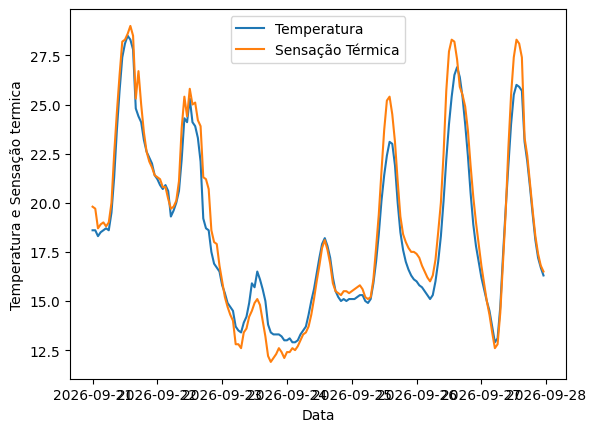

In [21]:
#Plote temperatura e sencacao_termica

import matplotlib.pyplot as plt

x = df['data_hora']
y1 = df['temperatura']
y2 = df['sensacao_termica']

plt.plot(x, y1, x, y2)
plt.xlabel("Data")
plt.ylabel("Temperatura e Sensação termica")
plt.legend(["Temperatura", "Sensação Térmica"])
plt.show()

#Numeros da megasena: 07 - 14 - 23 - 31 - 42 - 56
